In [1]:
from google.colab import files
uploaded=files.upload()

Saving WineQT (1).csv to WineQT (1).csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

print("="*60)
print("Libraries Imported Successfully")
print("="*60)

Libraries Imported Successfully


In [4]:
df = pd.read_csv("WineQT (1).csv")

In [5]:
print("\nFirst Five Rows")
print(df.head())


First Five Rows
      0  volatile acidity  citric acid  residual sugar  chlorides  \
0   7.4              0.70         0.00             1.9      0.076   
1   7.8              0.88         0.00             2.6      0.098   
2   7.8              0.76         0.04             2.3      0.092   
3  11.2              0.28         0.56             1.9      0.075   
4   7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9.8        5   2  
3      9.8        6

In [6]:
print("\nDataset Information")
print(df.info())

print("\nShape of Dataset")
print(df.shape)

print("\nColumn Names")
print(df.columns)



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   0                     1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
None

Shape of Dataset
(1143, 13)

Column Names
Index(

In [7]:

print("\nMissing Values")
print(df.isnull().sum())

# If missing values exist, remove them.
df = df.dropna()




Missing Values
0                       0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [8]:
print("\nStatistical Summary")
print(f"Shape of DataFrame before describe(): {df.shape}")
print(df.describe())


Statistical Summary
Shape of DataFrame before describe(): (1143, 13)
                 0  volatile acidity  citric acid  residual sugar  \
count  1143.000000       1143.000000  1143.000000     1143.000000   
mean      8.311111          0.531339     0.268364        2.532152   
std       1.747595          0.179633     0.196686        1.355917   
min       4.600000          0.120000     0.000000        0.900000   
25%       7.100000          0.392500     0.090000        1.900000   
50%       7.900000          0.520000     0.250000        2.200000   
75%       9.100000          0.640000     0.420000        2.600000   
max      15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925

In [9]:
X = df.drop(['quality', 'Id'], axis=1)

print("\nFeatures")
print(X.head())


Features
      0  volatile acidity  citric acid  residual sugar  chlorides  \
0   7.4              0.70         0.00             1.9      0.076   
1   7.8              0.88         0.00             2.6      0.098   
2   7.8              0.76         0.04             2.3      0.092   
3  11.2              0.28         0.56             1.9      0.075   
4   7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  
0      9.4  
1      9.8  
2      9.8  
3      9.8  
4      9.4  


In [10]:
X = df.drop(['quality', 'Id'], axis=1)

print("\nTarget")
print(X.head())


Target
      0  volatile acidity  citric acid  residual sugar  chlorides  \
0   7.4              0.70         0.00             1.9      0.076   
1   7.8              0.88         0.00             2.6      0.098   
2   7.8              0.76         0.04             2.3      0.092   
3  11.2              0.28         0.56             1.9      0.075   
4   7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  
0      9.4  
1      9.8  
2      9.8  
3      9.8  
4      9.4  


In [11]:
X = df.drop(['quality', 'Id'], axis=1)
y = df['quality']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42)

print("\nTraining Data Shape")
print(X_train.shape)

print("\nTesting Data Shape")
print(X_test.shape)


Training Data Shape
(914, 11)

Testing Data Shape
(229, 11)


In [13]:
model = LogisticRegression()

print("\nLogistic Regression Model Created")



Logistic Regression Model Created


In [14]:
model.fit(X_train, y_train)

print("\nModel Training Completed")


Model Training Completed


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
prediction = model.predict(X_test)

print("\nPrediction Completed")


Prediction Completed


In [16]:
comparison = pd.DataFrame({
    "Actual Profit": y_test.values,
    "Predicted Profit": prediction
})

print("\nActual vs Predicted")
print(comparison.head(20))


Actual vs Predicted
    Actual Profit  Predicted Profit
0               5                 5
1               6                 5
2               5                 5
3               6                 6
4               6                 6
5               8                 7
6               5                 5
7               5                 5
8               6                 6
9               5                 5
10              7                 7
11              6                 6
12              6                 6
13              6                 6
14              5                 6
15              6                 5
16              5                 5
17              5                 6
18              5                 5
19              6                 6


In [17]:
mae = mean_absolute_error(y_test, prediction)

mse = mean_squared_error(y_test, prediction)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, prediction)

print("\nMODEL PERFORMANCE")
print("-"*40)

print("Mean Absolute Error :", mae)

print("Mean Squared Error :", mse)

print("Root Mean Squared Error :", rmse)

print("R2 Score :", r2)

NameError: name 'mean_absolute_error' is not defined

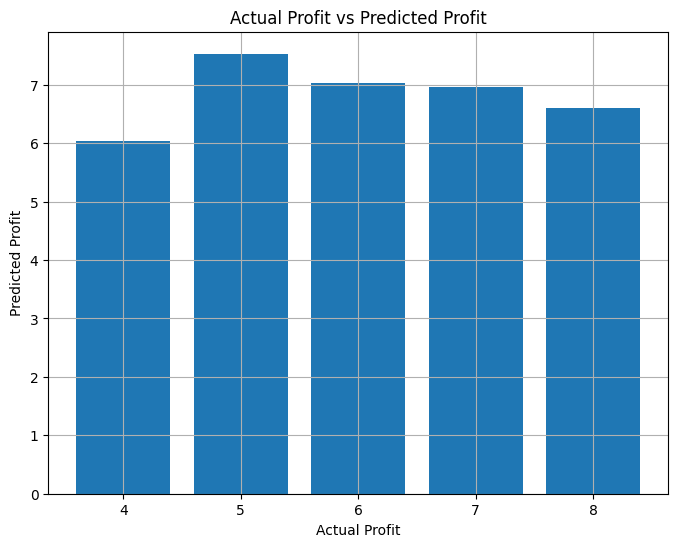

In [ ]:
plt.figure(figsize=(8,6))

plt.bar(
    y_test,
    prediction
)

plt.xlabel("Actual Profit")

plt.ylabel("Predicted Profit")

plt.title("Actual Profit vs Predicted Profit")

plt.grid(True)

plt.show()

Day 8

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Iris.csv to Iris.csv


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [ ]:
import pandas as pd

# STEP 1: LOAD DATA
df = pd.read_csv("/content/Iris.csv")

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

# Define target_col based on expected column names
if "target" in df.columns:
    target_col = "target"
elif "condition" in df.columns:
    target_col = "condition"
elif "num" in df.columns:
    target_col = "num"
elif "Species" in df.columns:
    target_col = "Species"
else:
    raise ValueError("Dataset must contain 'target', 'condition', 'num', or 'Species' column.")

df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [ ]:
import pandas as pd

# STEP 1: LOAD DATA
df = pd.read_csv("/content/Iris.csv")

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

# Define target_col based on expected column names
if "target" in df.columns:
    target_col = "target"
elif "condition" in df.columns:
    target_col = "condition"
elif "num" in df.columns:
    target_col = "num"
elif "Species" in df.columns:
    target_col = "Species"
else:
    raise ValueError("Dataset must contain 'target', 'condition', 'num', or 'Species' column.")

df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay)

In [ ]:
# STEP 1 : LOAD DATASET
# ==========================================================
print("="*70)
print("STEP 1 : Loading Dataset")
print("="*70)

df = pd.read_csv("Iris.csv")

print(df.head())
print("\nDataset Shape:", df.shape)

STEP 1 : Loading Dataset
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Shape: (150, 6)


In [ ]:
# STEP 2 : BASIC INFORMATION
# ==========================================================
print("\nSTEP 2 : Dataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe(include="all"))


STEP 2 : Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

Missing Values
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Statistical Summary
                Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
count   150.000000     150.000000    150.000000     150.000000    150.000000   
unique         NaN            NaN           NaN            NaN           NaN   
top            NaN            NaN          

In [ ]:
# STEP 3 : CHECK MISSING VALUES
# ===============================================================

print("\nMissing Values")
missing_values = df.isnull().sum()
print(missing_values)

# Remove completely empty columns
cols_to_drop = missing_values[missing_values == len(df)].index

if len(cols_to_drop) > 0:
    df.drop(columns=cols_to_drop, inplace=True)
    print("\nDropped Columns:", list(cols_to_drop))

# Remove rows containing missing values
df.dropna(inplace=True)


Missing Values
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [ ]:
# STEP 4 : SELECT FEATURES
# ===============================================================

X = df[["Id", "SepalLengthCm", "SepalWidthCm","PetalLengthCm","PetalWidthCm"]]

print("\nFeatures")
print(X.head())


Features
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0   1            5.1           3.5            1.4           0.2
1   2            4.9           3.0            1.4           0.2
2   3            4.7           3.2            1.3           0.2
3   4            4.6           3.1            1.5           0.2
4   5            5.0           3.6            1.4           0.2


In [ ]:
# STEP 5: TARGET VARIABLE
# ===============================================================

y = df["Species"]

print("\nTarget Variable")
print(y.head())


Target Variable
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object


In [ ]:
# STEP 6: SPLIT
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

models = {
    "Logistic Regression":
        Pipeline([("scaler", StandardScaler()),StandardScaler()

Machine learning algorithms
                  ("model", LogisticRegression(max_iter=1000))]),
              preprocessing and model training in sequence.
    "Decision Tree": predictions by asking a series of questions.
        DecisionTreeClassifier(random_state=42),

    "Random Forest":combines many Decision Trees.
        RandomForestClassifier(random_state=42),

    "KNN":"KNN":
Pipeline([
("scaler", StandardScaler()),
("model", KNeighborsClassifier())
]),

KNN classifies a sample based on the classes of its nearest neighbors
        Pipeline([("scaler", StandardScaler()),
                  ("model", KNeighborsClassifier())]),

    "SVM":
        Pipeline([("scaler", StandardScaler()),
                  ("model", SVC(probability=True))]),

    "Naive Bayes":It calculates the probability
        GaussianNB()
}

results = []

print("\n==========================")
print("MODEL EVALUATION")
print("==========================")

best_model = None
best_auc = -1

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test)
    else:
      prob = None

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, pred, average='weighted', zero_division=0)


    if prob is not None:
        auc = roc_auc_score(y_test, prob, multi_class='ovr', average='weighted')
    else:
        auc = np.nan

    cv = cross_val_score(model, X, y, cv=5, scoring="accuracy")

    print("\n", "="*60)
    print(name)
    print("="*60)
    print("Accuracy :", round(acc,4))
    print("Precision:", round(prec,4))
    print("Recall   :", round(rec,4))
    print("F1 Score :", round(f1,4))
    print("ROC AUC  :", round(auc,4))
    print("CV Mean  :", round(cv.mean(),4))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test,pred))

    print("\nClassification Report")
    print(classification_report(y_test,pred, zero_division=0))

    if prob is not None:
      pass

    results.append([name,acc,prec,rec,f1,auc,cv.mean()])

    if auc > best_auc or (pd.isna(auc) and best_auc == -1): # Handle NaN for auc comparison
        best_auc = auc
        best_model = (name, model)

summary = pd.DataFrame(
    results,
    columns=[
        "Model","Accuracy","Precision","Recall",
        "F1","ROC_AUC","CV Accuracy"
    ]
)


MODEL EVALUATION

Logistic Regression
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0
CV Mean  : 0.9933

Confusion Matrix
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30


Decision Tree
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0
CV Mean  : 0.9333

Confusion Matrix
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00    